<a href="https://colab.research.google.com/github/ajsarsva/video-captioning-thesis/blob/main/day6_frame_extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Master Cell

In [1]:
# ============================================
# MASTER SETUP CELL — Run this every session
# ============================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Restore Kaggle credentials
import shutil, os
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# 3. Clone or pull GitHub repo
if os.path.exists('/content/video-captioning-thesis'):
    %cd /content/video-captioning-thesis
    !git pull origin main
else:
    !git clone https://github.com/ajsarsva/video-captioning-thesis.git
    %cd /content/video-captioning-thesis

# 4. Add src/ to path so we can import our modules
import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Drive mounted")
print("✅ Kaggle ready")
print("✅ Repo ready")
print("✅ Ready to work!")

Mounted at /content/drive
Cloning into 'video-captioning-thesis'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 26 (delta 7), reused 9 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 14.17 KiB | 7.08 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/video-captioning-thesis
✅ Drive mounted
✅ Kaggle ready
✅ Repo ready
✅ Ready to work!


Testing frame extractor on 5 videos

In [4]:
import sys
import cv2
sys.path.append('/content/video-captioning-thesis/src')

from frame_extractor import extract_frames, get_video_info

# Test on 5 videos
video_dir = '/content/drive/MyDrive/thesis-data/videos/'
test_videos = [f'video{i}.mp4' for i in range(5)]

for vid_name in test_videos:
    video_path = os.path.join(video_dir, vid_name)

    # Get info first
    info = get_video_info(video_path)

    # Extract frames
    frames, fps, total = extract_frames(video_path)

    print(f"{vid_name}:")
    print(f"  FPS: {info['fps']:.1f}")
    print(f"  Duration: {info['duration_seconds']:.1f} seconds")
    print(f"  Total frames extracted: {len(frames)}")
    print(f"  Frame size: {frames[0].shape}")
    print()

video0.mp4:
  FPS: 25.0
  Duration: 12.0 seconds
  Total frames extracted: 300
  Frame size: (240, 320, 3)

video1.mp4:
  FPS: 25.0
  Duration: 22.0 seconds
  Total frames extracted: 550
  Frame size: (240, 320, 3)

video2.mp4:
  FPS: 30.0
  Duration: 10.0 seconds
  Total frames extracted: 299
  Frame size: (240, 320, 3)

video3.mp4:
  FPS: 24.0
  Duration: 10.0 seconds
  Total frames extracted: 240
  Frame size: (240, 320, 3)

video4.mp4:
  FPS: 30.0
  Duration: 10.0 seconds
  Total frames extracted: 300
  Frame size: (240, 320, 3)



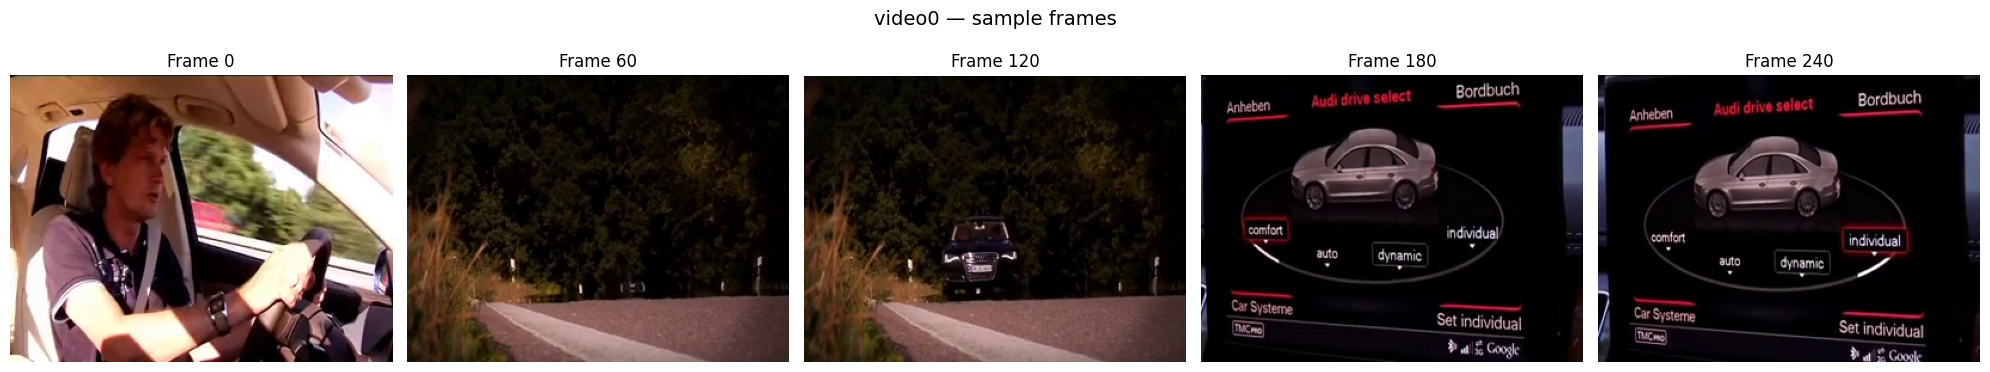

Test figure saved to Drive!


In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# Extract frames from video0
frames, fps, total = extract_frames('/content/drive/MyDrive/thesis-data/videos/video0.mp4')

# Show 5 evenly spaced frames
indices = [int(i * len(frames) / 5) for i in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('video0 — sample frames', fontsize=14)

for i, idx in enumerate(indices):
    frame_rgb = cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB)
    axes[i].imshow(frame_rgb)
    axes[i].set_title(f'Frame {idx}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/results/frame_extractor_test.png')
plt.show()
print("Test figure saved to Drive!")